In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [78]:
transit_emissions = pd.read_csv("../data/ghg-emissions-transport-en.csv", skiprows=2)
transit_emissions = transit_emissions.head(35)
transit_emissions.columns

Index(['Year', 'Passenger - Cars (megatonnes of carbon dioxide equivalent)',
       'Passenger - Light trucks (megatonnes of carbon dioxide equivalent)',
       'Passenger - Motorcycles, bus, rail, aviation and marine (megatonnes of carbon dioxide equivalent)',
       'Freight - Heavy duty trucks (megatonnes of carbon dioxide equivalent)',
       'Freight - Rail, aviation and marine (megatonnes of carbon dioxide equivalent)',
       'Other (megatonnes of carbon dioxide equivalent)'],
      dtype='str')

In [79]:
transit_emissions = transit_emissions.rename(columns= { 'Year' : 'year',
                                                        'Passenger - Cars (megatonnes of carbon dioxide equivalent)' : 'cars',
                                                        'Passenger - Light trucks (megatonnes of carbon dioxide equivalent)' : 'light_trucks',
                                                        'Passenger - Motorcycles, bus, rail, aviation and marine (megatonnes of carbon dioxide equivalent)' : 'passenger_other',
                                                        'Freight - Heavy duty trucks (megatonnes of carbon dioxide equivalent)' : 'heavy_trucks',
                                                        'Freight - Rail, aviation and marine (megatonnes of carbon dioxide equivalent)' : 'freight_other',
                                                        'Other (megatonnes of carbon dioxide equivalent)' : 'other' })
transit_emissions["total"] = transit_emissions.drop("year", axis = 1).sum(axis=1)
transit_emissions


,year,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total
0,1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9
1,1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3
2,1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2
3,1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3
4,1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3
5,1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4
6,1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1
7,1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4
8,1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5
9,1999,43.1,36.3,10.1,27.2,9.9,12.8,139.4


In [80]:
transit_emissions["year_over_year"] = (transit_emissions["total"] - transit_emissions.shift(1)["total"]).round(2)
transit_emissions["year_over_year_pct"] = (transit_emissions["year_over_year"] / transit_emissions.shift(1)["total"] * 100).round(2)
transit_emissions

,year,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct
0,1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN
1,1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93
2,1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69
3,1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71
4,1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12
5,1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4,2.1,1.70
6,1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1,2.7,2.15
7,1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4,4.3,3.36
8,1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5,3.1,2.34
9,1999,43.1,36.3,10.1,27.2,9.9,12.8,139.4,3.9,2.88


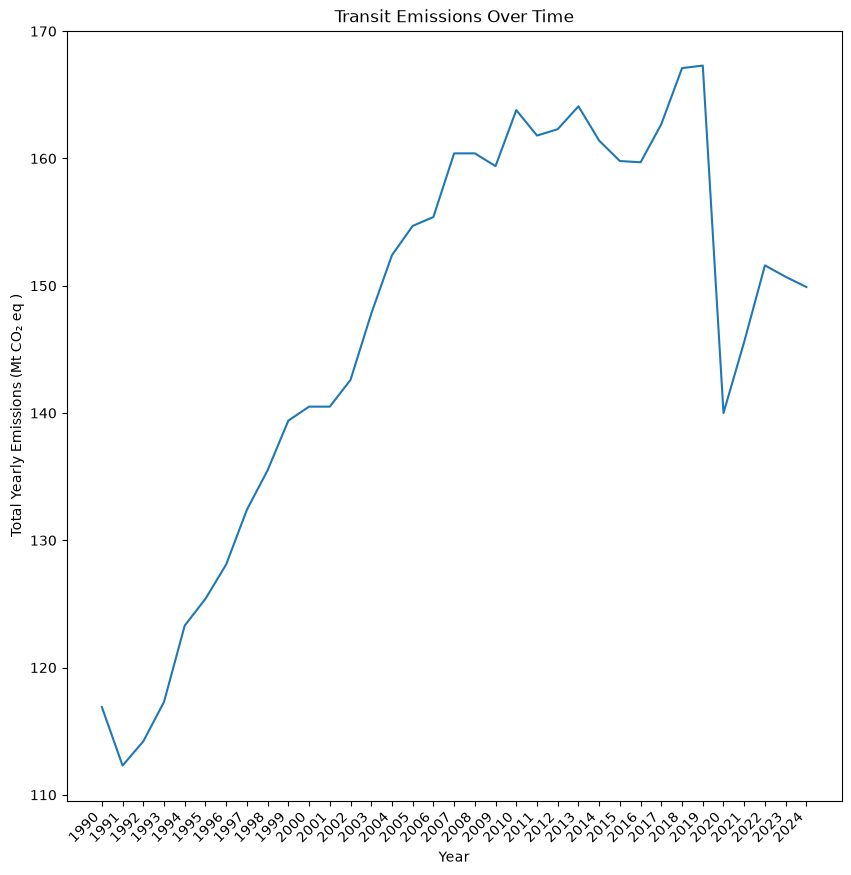

In [81]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(transit_emissions["year"], transit_emissions["total"])
ax.set_title("Transit Emissions Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Total Yearly Emissions (Mt CO₂ eq )")
plt.xticks(rotation=45, ha='right')


plt.show()

Questions to answer:

When did emissions peak?

When did the largest increase occur.

Emissions Peaked in 2019, then dropped dramatically in 2020.

The largest increases occurred in the 90 with the greatest being in 1994.

Also there was a sharp increase from 2021 onwards with 2022 being roughly equal (+- 0.2) with 1994 for year over year increase.

There was a 27.3 (16.32%) megatonne co2 decrease in 2020.

In [82]:
transit_emissions = transit_emissions.set_index("year")
emissions_2019_to_2024 = transit_emissions.at['2024', 'total'] - transit_emissions.at['2019', "total"]
emissions_2019_to_2024_pct = (transit_emissions.at['2024', 'total'] - transit_emissions.at['2019', 'total']) / transit_emissions.at['2019', 'total'] * 100
emissions_2019_to_2024


np.float64(-17.400000000000034)

In [83]:
emissions_2019_to_2024_pct

np.float64(-10.40047818290498)

There has been a 17.4 (10.4%) megatonne co2 decrease from estimations in 2019 to estimation in 2024.

In [84]:
emissions_1990_to_2024 = transit_emissions.at['2024', 'total'] - transit_emissions.at['1990', "total"]
emissions_1990_to_2024_pct = (transit_emissions.at['2024', 'total'] - transit_emissions.at['1990', 'total']) / transit_emissions.at['1990', 'total'] * 100
emissions_1990_to_2024

np.float64(32.999999999999986)

In [85]:
emissions_1990_to_2024_pct

np.float64(28.229255774165946)

There has been a 33.0 (28.22%) megatonne co2 increase from 1990 to 2024.

In [86]:
emissions_1990_to_2019 = transit_emissions.at['2019', 'total'] - transit_emissions.at['1990', "total"]
emissions_1990_to_2019_pct = (transit_emissions.at['2019', 'total'] - transit_emissions.at['1990', 'total']) / transit_emissions.at['1990', 'total'] * 100
emissions_1990_to_2019

np.float64(50.40000000000002)

In [87]:
emissions_1990_to_2019_pct

np.float64(43.11377245508984)

There has been a 50.4 (43.11%) megatonne co2 increase from 1990 to 2019.

How have transportation categories changed over time and which are responsible for long-term increases and decreases?

In [88]:
transit_emissions_flipped = transit_emissions[["cars", "light_trucks",	"passenger_other",	"heavy_trucks",	"freight_other", "other", "total"]].T

#add faceted visualization of all emission history for each category
transit_emissions_flipped = transit_emissions_flipped[["1990", "2024"]]
transit_emissions_flipped["delta"] = transit_emissions_flipped["2024"] - transit_emissions_flipped["1990"]
transit_emissions_flipped["delta_pct"] = ((transit_emissions_flipped["2024"] - transit_emissions_flipped["1990"]) / transit_emissions_flipped["1990"] * 100).round(2)
transit_emissions_flipped = transit_emissions_flipped.reset_index()
transit_emissions_flipped.rename(columns= {"index" : "categories"})
transit_emissions_flipped

year,index,1990,2024,delta,delta_pct
0,cars,44.8,24.2,-20.6,-45.98
1,light_trucks,25.9,55.0,29.1,112.36
2,passenger_other,9.0,12.3,3.3,36.67
3,heavy_trucks,19.2,35.7,16.5,85.94
4,freight_other,9.8,9.0,-0.8,-8.16
5,other,8.2,13.7,5.5,67.07
6,total,116.9,149.9,33.0,28.23


From the table we can see that the amount of emissions from cars has decreased by nearly 50%

The emissions from light trucks has more than doubled.

The emissions from heavy trucks has increased signicantly from 1940.

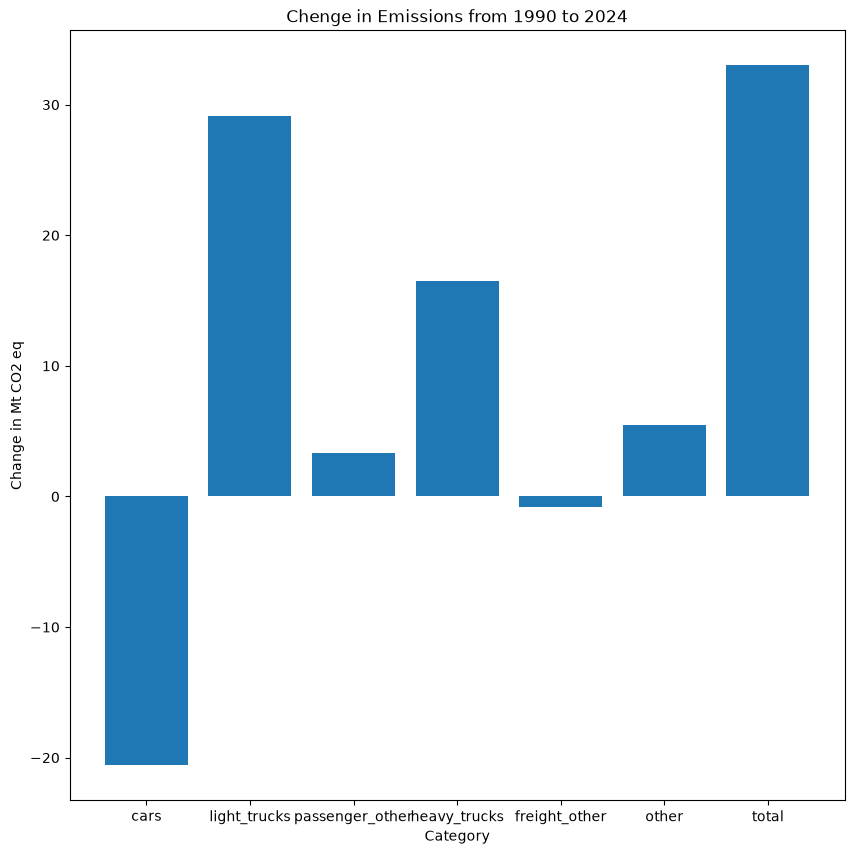

In [89]:
fig, ax = plt.subplots(figsize= (10, 10))

ax.bar(transit_emissions_flipped["index"], transit_emissions_flipped["delta"])
ax.set_title("Chenge in Emissions from 1990 to 2024")
ax.set_xlabel("Category")
ax.set_ylabel("Change in Mt CO2 eq")
plt.show()

How has the composition of transportation emissions changed?

In [90]:
transit_emissions_narrow = transit_emissions.reset_index()[["year", "cars", "light_trucks",	"passenger_other",	"heavy_trucks",	"freight_other","other"]]
transit_emissions_narrow = transit_emissions_narrow.melt(id_vars="year", var_name="category", value_name="emissions").sort_values("year")
transit_emissions_narrow = transit_emissions_narrow[(transit_emissions_narrow["year"] == "1990")  | (transit_emissions_narrow["year"] == "2005") |(transit_emissions_narrow["year"] == "2020") | (transit_emissions_narrow["year"] == "2024")]
transit_emissions_narrow["pct_total"] = (transit_emissions_narrow["emissions"] / transit_emissions_narrow.groupby("year")["emissions"].transform("sum") * 100).round(2)
transit_emissions_narrow.groupby("year").head(20)
transit_emissions_narrow_pivoted = transit_emissions_narrow.pivot(index=["year"], columns="category", values="pct_total")
transit_emissions_narrow_pivoted

category,cars,freight_other,heavy_trucks,light_trucks,other,passenger_other
year,,,,,,
1990,38.32,8.38,16.42,22.16,7.01,7.70
2005,27.08,6.92,22.88,27.34,8.79,6.98
2020,17.79,7.36,24.50,34.86,9.50,6.00
2024,16.14,6.00,23.82,36.69,9.14,8.21


We see that the proportion of emissions from cars has decreased since 1990.

Conversely we see that the proportion of emissions by light trucks has increased.

Follow up question: How has the proportion of emissions from freight vs passenger vehicles compare?

In [91]:
transit_emissions_narrow_pivoted["passenger"] = transit_emissions_narrow_pivoted["cars"] + transit_emissions_narrow_pivoted["light_trucks"] + transit_emissions_narrow_pivoted["passenger_other"]
transit_emissions_narrow_pivoted["freight"] = transit_emissions_narrow_pivoted["freight_other"] + transit_emissions_narrow_pivoted["heavy_trucks"]
transit_emissions_passenger_vs_freight = transit_emissions_narrow_pivoted[["passenger", "freight", "other"]]
transit_emissions_narrow_pivoted = transit_emissions_narrow_pivoted[["cars", "light_trucks",	"passenger_other",	"heavy_trucks",	"freight_other","other"]]
transit_emissions_passenger_vs_freight

category,passenger,freight,other
year,,,
1990,68.18,24.80,7.01
2005,61.40,29.80,8.79
2020,58.65,31.86,9.50
2024,61.04,29.82,9.14


We can see that the proportion of emissions contributed by passenger vehicles has decreased  and the proportion of emissions contributed by freight vehicles has increased since 1990.

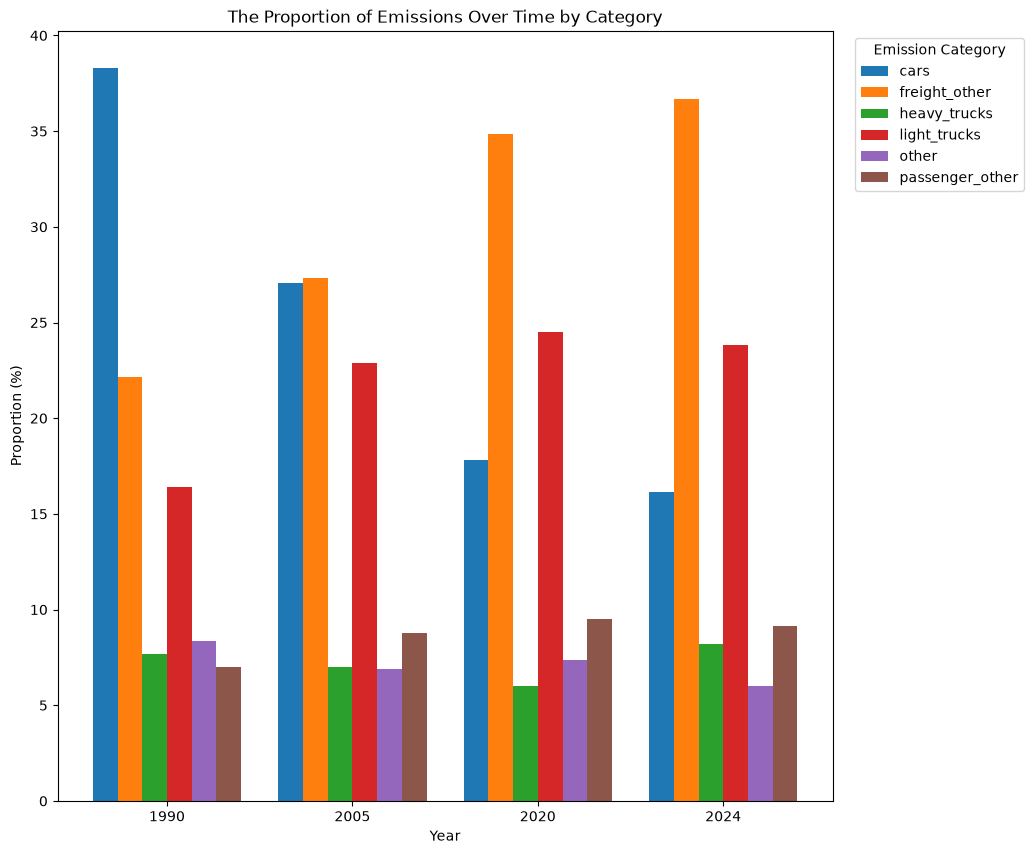

In [92]:
fig, ax = plt.subplots(figsize=(10, 10))
categories = ["cars","freight_other","heavy_trucks", "light_trucks","other","passenger_other"]

ax.grouped_bar(transit_emissions_narrow_pivoted, labels=categories)
ax.set_xlabel("Year")
ax.set_ylabel("Proportion (%)")
ax.set_title("The Proportion of Emissions Over Time by Category")
ax.legend(title="Emission Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

How has Canada's emission production changed on a per capita level?

In [93]:
population = pd.read_csv("../data/Canada-Population-Population-2026-09-05-16-09.csv")
population = population.rename(columns= {"Unnamed: 0" : "year", "Population" : "population"})
population = population[population["year"].between(1990, 2024)]
population = population.set_index("year")

In [94]:
transit_emissions.index = transit_emissions.index.astype(int)
transit_emissions = transit_emissions.join(population, how='left')
transit_emissions.style.format( {'population' : '{:.2e}'})
transit_emissions

,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct,population
year,,,,,,,,,,
1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN,27657204
1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93,28015761
1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69,28347641
1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71,28668166
1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12,28981189
1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4,2.1,1.70,29289423
1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1,2.7,2.15,29593849
1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4,4.3,3.36,29882752
1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5,3.1,2.34,30144812


In [95]:
transit_emissions["emissions_per_capita"] = (transit_emissions["total"] * pow(10, 6)  / transit_emissions["population"]).round(2) #emissions now in tonnes
transit_emissions

,cars,light_trucks,passenger_other,heavy_trucks,freight_other,other,total,year_over_year,year_over_year_pct,population,emissions_per_capita
year,,,,,,,,,,,
1990,44.8,25.9,9.0,19.2,9.8,8.2,116.9,NaN,NaN,27657204,4.23
1991,43.5,25.5,8.0,17.8,9.8,7.7,112.3,-4.6,-3.93,28015761,4.01
1992,44.2,26.5,8.0,18.3,9.5,7.7,114.2,1.9,1.69,28347641,4.03
1993,45.2,27.7,7.8,19.2,9.6,7.8,117.3,3.1,2.71,28668166,4.09
1994,46.0,29.3,8.2,21.4,10.1,8.3,123.3,6.0,5.12,28981189,4.25
1995,44.5,29.8,8.6,22.7,10.1,9.7,125.4,2.1,1.70,29289423,4.28
1996,44.3,31.1,9.1,23.5,10.0,10.1,128.1,2.7,2.15,29593849,4.33
1997,43.9,32.8,9.4,25.2,10.1,11.0,132.4,4.3,3.36,29882752,4.43
1998,43.7,34.7,9.7,25.7,9.9,11.8,135.5,3.1,2.34,30144812,4.49


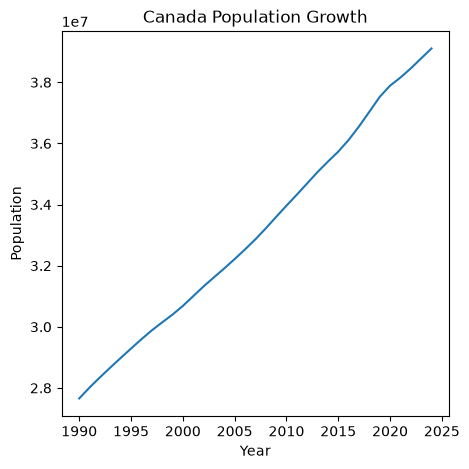

In [96]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(transit_emissions.index, transit_emissions["population"])
ax.set_title("Canada Population Growth")
ax.set_xlabel("Year")
ax.set_ylabel("Population")


plt.show()

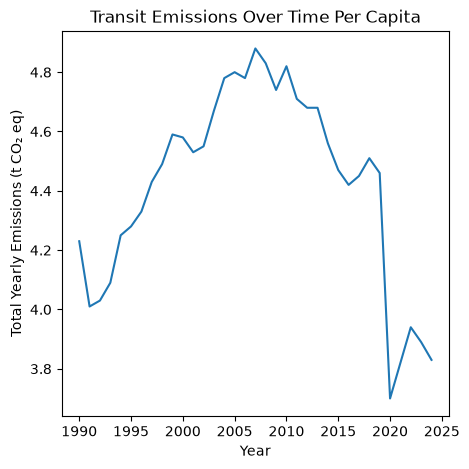

In [97]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(transit_emissions.index, transit_emissions["emissions_per_capita"])
ax.set_title("Transit Emissions Over Time Per Capita")
ax.set_xlabel("Year")
ax.set_ylabel("Total Yearly Emissions (t CO₂ eq)")


plt.show()

The Per Capita View gives a greater overall picture of Canada's emissions trends. We see that the per capita emissions peaked in 2007 and has declined since then.

We also see the massive dip in 2020.

Some of the year to year increases in emissions can be attributed to a growing population

Some other possible variables to explore:
- fuel consumption
- fuel prices
- vehicle efficiency
- EV adoption and switch to electric
- GDP

How does GDP affect Emissions?


In [114]:
gdp = pd.read_csv("../data/3610069901-eng.csv", skiprows=10)
gdp = gdp[gdp["Estimates"] == "Gross domestic product at market prices"]
gdp = gdp.T.drop("Estimates").reset_index()
gdp = gdp.rename(columns={1 : 'gdp', "index" : "year"})
gdp

,year,gdp
0,1990,"1,159,666"
1,1991,"1,135,417"
2,1992,"1,145,527"
3,1993,"1,175,972"
4,1994,"1,228,821"
5,1995,"1,261,782"
6,1996,"1,283,093"
7,1997,"1,338,011"
8,1998,"1,390,098"
9,1999,"1,461,563"


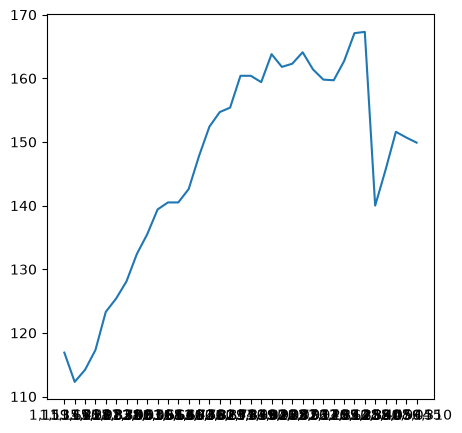

In [119]:
fig, ax = plt.subplots(figsize= (5, 5))

ax.plot(gdp["gdp"], transit_emissions["total"])
plt.show()